In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os, time

np.random.seed(0)
%matplotlib inline

In [ ]:
def jacobi_eigenvalue(S, tol=1e-10, max_sweeps=100):
    A = S.copy().astype(np.float64)
    n = A.shape[0]
    V = np.eye(n)

    for sweep in range(max_sweeps):
        off_diag_energy = np.sqrt(2.0 * np.sum(np.triu(A, 1) ** 2))
        if off_diag_energy < tol:
            break

        for p in range(n - 1):
            for q in range(p + 1, n):
                apq = A[p, q]
                if abs(apq) < 1e-14:
                    continue

                app, aqq = A[p, p], A[q, q]
                if abs(app - aqq) < 1e-14:
                    theta = np.pi / 4.0 if apq > 0 else -np.pi / 4.0
                else:
                    theta = 0.5 * np.arctan2(2.0 * apq, app - aqq)

                c, s = np.cos(theta), np.sin(theta)

                row_p, row_q = A[p, :].copy(), A[q, :].copy()
                A[p, :] = c * row_p + s * row_q
                A[q, :] = -s * row_p + c * row_q

                col_p, col_q = A[:, p].copy(), A[:, q].copy()
                A[:, p] = c * col_p + s * col_q
                A[:, q] = -s * col_p + c * col_q
                vcol_p, vcol_q = V[:, p].copy(), V[:, q].copy()
                V[:, p] = c * vcol_p + s * vcol_q
                V[:, q] = -s * vcol_p + c * vcol_q

    eigvals = np.diag(A).copy()
    return eigvals, V

In [ ]:
M = np.random.randn(6, 6)
S_test = M @ M.T

eigvals, V = jacobi_eigenvalue(S_test)
order = np.argsort(eigvals)[::-1]
eigvals, V = eigvals[order], V[:, order]

reconstruction_error = np.linalg.norm(S_test - V @ np.diag(eigvals) @ V.T)
orthogonality_error = np.linalg.norm(V.T @ V - np.eye(6))

print('Eigenvalues:', np.round(eigvals, 4))
print(f'Reconstruction error  ||S - V L V^T||: {reconstruction_error:.2e}')
print(f'Orthogonality error   ||V^T V - I||:   {orthogonality_error:.2e}')

Eigenvalues: [22.468  11.2087  8.5679  2.6509  0.8673  0.256 ]
Reconstruction error  ||S - V L V^T||: 7.17e-11
Orthogonality error   ||V^T V - I||:   1.31e-15


In [ ]:
def svd_from_scratch(A, verbose=False):
    A = A.astype(np.float64)
    m, n = A.shape
    r = min(m, n)

    if n <= m:
        AtA = A.T @ A
        eigvals, V = jacobi_eigenvalue(AtA)
        order = np.argsort(eigvals)[::-1]
        eigvals, V = eigvals[order], V[:, order]
        eigvals = np.clip(eigvals[:r], 0, None)
        sigma = np.sqrt(eigvals)
        V = V[:, :r]

        U = np.zeros((m, r))
        for i in range(r):
            if sigma[i] > 1e-10:
                U[:, i] = (A @ V[:, i]) / sigma[i]
            else:
                U[:, i] = 0.0
    else:
        AAt = A @ A.T
        eigvals, U = jacobi_eigenvalue(AAt)
        order = np.argsort(eigvals)[::-1]
        eigvals, U = eigvals[order], U[:, order]
        eigvals = np.clip(eigvals[:r], 0, None)
        sigma = np.sqrt(eigvals)
        U = U[:, :r]

        V = np.zeros((n, r))
        for i in range(r):
            if sigma[i] > 1e-10:
                V[:, i] = (A.T @ U[:, i]) / sigma[i]
            else:
                V[:, i] = 0.0

    if verbose:
        recon_err = np.linalg.norm(A - U @ np.diag(sigma) @ V.T) / np.linalg.norm(A)
        print(f'Relative reconstruction error: {recon_err:.2e}')

    return U, sigma, V.T

In [ ]:
A_test = np.random.randn(8, 5)
U, S, Vt = svd_from_scratch(A_test, verbose=True)

print('U shape:', U.shape, ' S shape:', S.shape, ' Vt shape:', Vt.shape)
print('Singular values:', np.round(S, 4))
print('U^T U (should be ~I):')
print(np.round(U.T @ U, 3))

Loaded image from /content/Screenshot_2026-09-03-22-43-25-91_40deb401b9ffe8e1df2f1cc5ba480b12.jpg, resized to (126, 128)


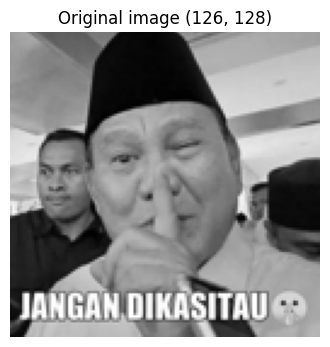

In [ ]:
IMAGE_PATH = '/content/Screenshot_2026-09-03-22-43-25-91_40deb401b9ffe8e1df2f1cc5ba480b12.jpg'
MAX_DIM = 128

def make_synthetic_image(size=128):
    x = np.linspace(-3, 3, size)
    y = np.linspace(-3, 3, size)
    xx, yy = np.meshgrid(x, y)
    img = (
        np.sin(2 * xx) * np.cos(2 * yy) * 60
        + np.exp(-(xx**2 + yy**2)) * 120
        + 40 * np.sin(xx * yy)
    )
    cy, cx = size // 2, size // 2
    Y, X = np.ogrid[:size, :size]
    circle_mask = (X - cx // 2) ** 2 + (Y - cy) ** 2 <= (size // 6) ** 2
    img[circle_mask] += 80
    img[size // 4: size // 4 + size // 8, size // 2:] += 60
    img = 128 + img
    img = np.clip(img, 0, 255)
    return img.astype(np.float64)

if os.path.exists(IMAGE_PATH):
    pil_img = Image.open(IMAGE_PATH).convert('L')
    w, h = pil_img.size
    scale = MAX_DIM / max(w, h)
    pil_img = pil_img.resize((max(1, int(w * scale)), max(1, int(h * scale))))
    img_array = np.array(pil_img, dtype=np.float64)
    print(f'Loaded image from {IMAGE_PATH}, resized to {img_array.shape}')
else:
    img_array = make_synthetic_image(MAX_DIM)
    print(f'No image found at {IMAGE_PATH} -- using a synthetic {img_array.shape} test image instead.')

plt.figure(figsize=(4, 4))
plt.imshow(img_array, cmap='gray')
plt.title(f'Original image {img_array.shape}')
plt.axis('off')
plt.show()

## 4. Run Our From-Scratch SVD on the Image

The image is just a matrix of pixel intensities — exactly what our `svd_from_scratch` expects.

In [ ]:
t0 = time.time()
U, S, Vt = svd_from_scratch(img_array)
elapsed = time.time() - t0

m, n = img_array.shape
r = len(S)
print(f'Image shape: {m} x {n}, rank computed: {r}')
print(f'SVD (from scratch) took {elapsed:.2f} seconds')

relative_error = np.linalg.norm(img_array - U @ np.diag(S) @ Vt) / np.linalg.norm(img_array)
print(f'Full-rank reconstruction relative error: {relative_error:.2e}')

Image shape: 126 x 128, rank computed: 126
SVD (from scratch) took 2.03 seconds
Full-rank reconstruction relative error: 2.63e-15


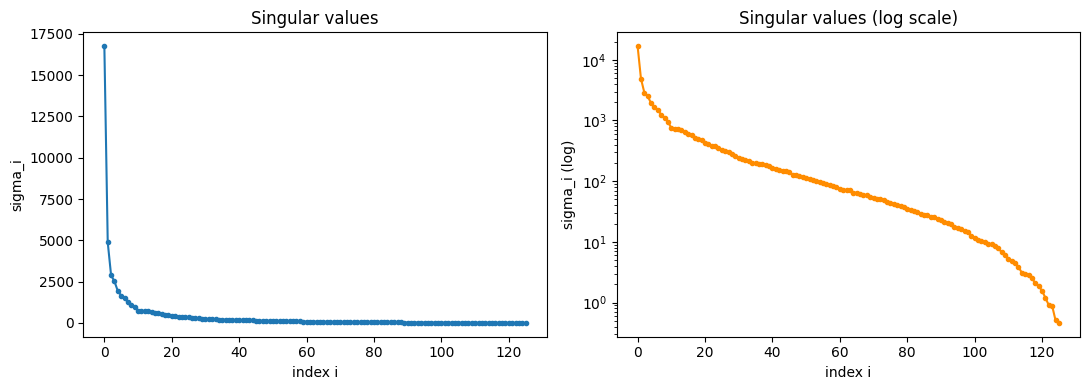

Rank needed to capture 90% of energy: k = 2 / 126
Rank needed to capture 99% of energy: k = 16 / 126


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(S, 'o-', markersize=3)
axes[0].set_title('Singular values')
axes[0].set_xlabel('index i')
axes[0].set_ylabel('sigma_i')

axes[1].semilogy(S, 'o-', markersize=3, color='darkorange')
axes[1].set_title('Singular values (log scale)')
axes[1].set_xlabel('index i')
axes[1].set_ylabel('sigma_i (log)')

plt.tight_layout()
plt.show()

energy = np.cumsum(S**2) / np.sum(S**2)
k90 = np.searchsorted(energy, 0.90) + 1
k99 = np.searchsorted(energy, 0.99) + 1
print(f'Rank needed to capture 90% of energy: k = {k90} / {r}')
print(f'Rank needed to capture 99% of energy: k = {k99} / {r}')

In [ ]:
def compress(U, S, Vt, k):
    return U[:, :k].copy(), S[:k].copy(), Vt[:k, :].copy()

def decompress(Uk, Sk, Vtk):
    return Uk @ np.diag(Sk) @ Vtk

def compression_ratio(m, n, k):
    original = m * n
    compressed = k * (m + n + 1)
    return original / compressed

def psnr(original, reconstructed, max_val=255.0):
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(max_val) - 10 * np.log10(mse)

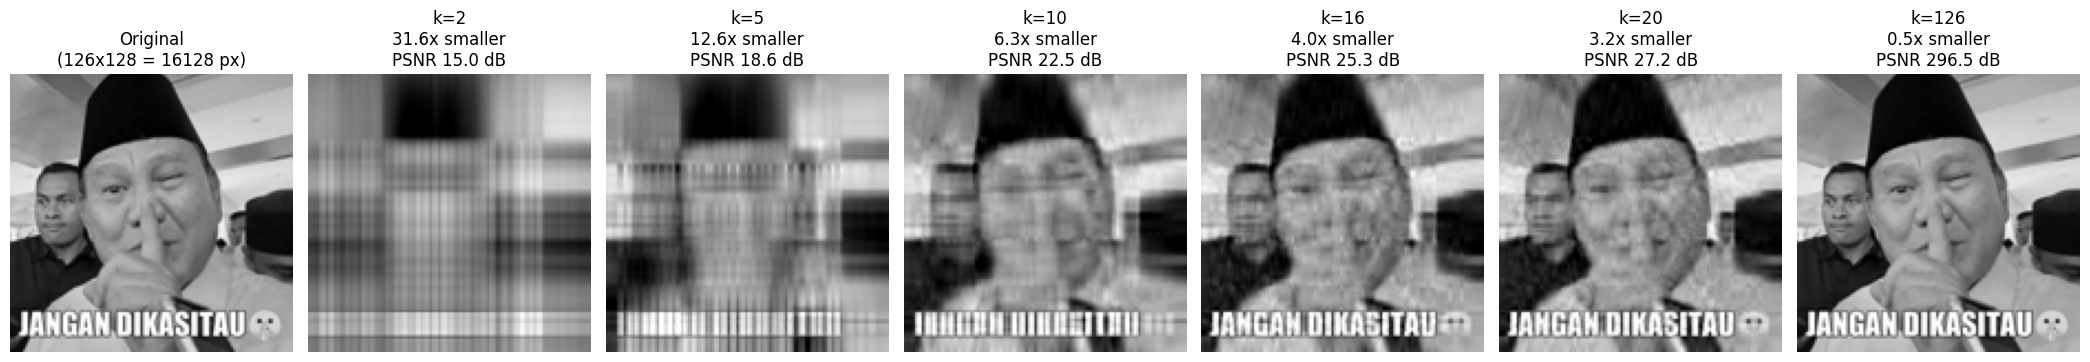

    k    compression ratio    PSNR (dB)
    2               31.62x        15.04
    5               12.65x        18.57
   10                6.32x        22.47
   16                3.95x        25.34
   20                3.16x        27.20
  126                0.50x       296.53


In [ ]:
k_values = [2, 5, 10, 20, k90, k99, r]
k_values = sorted(set(int(k) for k in k_values if 1 <= k <= r))

fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(3 * (len(k_values) + 1), 3.4))

axes[0].imshow(img_array, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f'Original\n({m}x{n} = {m*n} px)')
axes[0].axis('off')

results = []
for ax, k in zip(axes[1:], k_values):
    Uk, Sk, Vtk = compress(U, S, Vt, k)
    reconstructed = decompress(Uk, Sk, Vtk)
    reconstructed_clipped = np.clip(reconstructed, 0, 255)

    ratio = compression_ratio(m, n, k)
    quality = psnr(img_array, reconstructed)
    results.append((k, ratio, quality))

    ax.imshow(reconstructed_clipped, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'k={k}\n{ratio:.1f}x smaller\nPSNR {quality:.1f} dB')
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"{'k':>5} {'compression ratio':>20} {'PSNR (dB)':>12}")
for k, ratio, quality in results:
    print(f'{k:>5} {ratio:>19.2f}x {quality:>12.2f}')

k = 16
Original array on disk:   129,152 bytes
Compressed factors on disk: 33,366 bytes
Actual on-disk savings: 3.87x


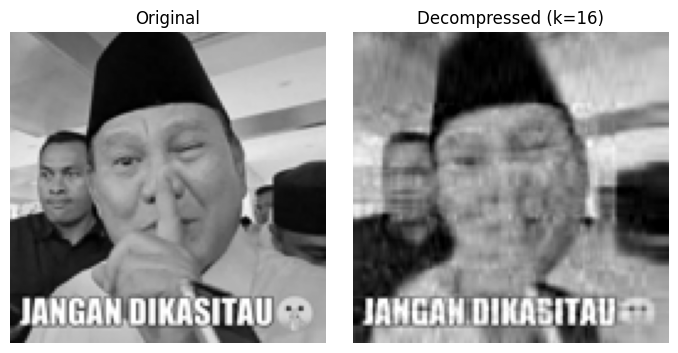

In [ ]:
CHOSEN_K = k99  # pick a rank that keeps 90% of the energy

Uk, Sk, Vtk = compress(U, S, Vt, CHOSEN_K)

os.makedirs('/tmp/svd_demo', exist_ok=True)
np.save('/tmp/svd_demo/original.npy', img_array)
np.savez('/tmp/svd_demo/compressed.npz', U=Uk, S=Sk, Vt=Vtk)

original_bytes = os.path.getsize('/tmp/svd_demo/original.npy')
compressed_bytes = os.path.getsize('/tmp/svd_demo/compressed.npz')

print(f'k = {CHOSEN_K}')
print(f'Original array on disk:   {original_bytes:,} bytes')
print(f'Compressed factors on disk: {compressed_bytes:,} bytes')
print(f'Actual on-disk savings: {original_bytes / compressed_bytes:.2f}x')

# decompress it back to confirm round-trip correctness
loaded = np.load('/tmp/svd_demo/compressed.npz')
reconstructed = decompress(loaded['U'], loaded['S'], loaded['Vt'])

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(img_array, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(np.clip(reconstructed, 0, 255), cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Decompressed (k={CHOSEN_K})')
axes[1].axis('off')
plt.tight_layout()
plt.show()